In [92]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [93]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [94]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [95]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [97]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors="coerce")

In [98]:
df['TotalCharges'].dtype

dtype('float64')

In [99]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [100]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [101]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [102]:
df.drop(columns="customerID",inplace=True)

In [103]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [121]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
x=df.drop(df['Churn'],axis=1)
y=df['Churn']

In [105]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [106]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [107]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
numeric_feature=x.select_dtypes(exclude="str").columns
one_param=x.select_dtypes(include="str").columns
Onemodel=OneHotEncoder(drop='first')
scaler=StandardScaler()
preprocessor=ColumnTransformer([
    ("onehotencoder",Onemodel,one_param),
    ("standard_scaler",scaler,numeric_feature)
])
x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.transform(x_test)

In [108]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [109]:
#Build our ANN model
model=Sequential([
    Dense(64,activation="relu",input_shape=(x_train.shape[1],)),Dropout(0.2),
    Dense(32,activation="relu"),Dropout(0.2),
    Dense(16,activation="relu"),Dropout(0.2),
    Dense(1,activation="sigmoid")
])

In [110]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
#complie the model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)


In [112]:
#setup the tensorboard
import os
# Format: YYYYMMDD-HHMMSS (Clean, safe, and chronologically sorts perfectly)
timestamp=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir=os.path.join("logs","fit",timestamp)
# Initialize the callback
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
print(f"safe log directory is created: {log_dir}")


safe log directory is created: logs\fit\20260903-161952


In [113]:
#setup early stopping
Early_Stop=EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

In [ ]:
#Train model
history=model.fit(x_train,y_train,
                  validation_data=(x_test,y_test),
                  epochs=100,
                  batch_size=32,
                  callbacks=[Early_Stop,tensorboard_callback])
model.save("ann_churn_model.keras")





Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7251 - loss: 0.5170 - val_accuracy: 0.8126 - val_loss: 0.4153
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7833 - loss: 0.4541 - val_accuracy: 0.8077 - val_loss: 0.4102
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7875 - loss: 0.4513 - val_accuracy: 0.8070 - val_loss: 0.4037
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7916 - loss: 0.4417 - val_accuracy: 0.8105 - val_loss: 0.4017
Epoch 5/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7948 - loss: 0.4356 - val_accuracy: 0.8077 - val_loss: 0.4049
Epoch 6/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7962 - loss: 0.4316 - val_accuracy: 0.8126 - val_loss: 0.4050
Epoch 7/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7991 - loss: 0.4319 - val_accuracy: 0.8098 - val_loss: 0.4057
Epoch 8/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7968 - loss: 0.4314 - val_accu

In [115]:
#load tensorboard extenstion
%load_ext tensorboard
%tensorboard --logdir ./logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6009 (pid 21540), started 0:06:03 ago. (Use '!kill 21540' to kill it.)

In [116]:
import pickle
import tensorflow as tf

# 1. Save your fitted ColumnTransformer (handles Scaling and One-Hot Encoding)
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

# 2. Save your fitted LabelEncoder (handles target Churn/No Churn mapping)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

# 3. Save your Trained Deep Learning Model (Keras native format)
model.save("ann_churn_model.keras")

print("🎉 All components successfully saved to your drive!")


🎉 All components successfully saved to your drive!


Plot Training PerformanceAdd this code block right below your training cell to visualize if your network is learning smoothly or experiencing over-fitting:

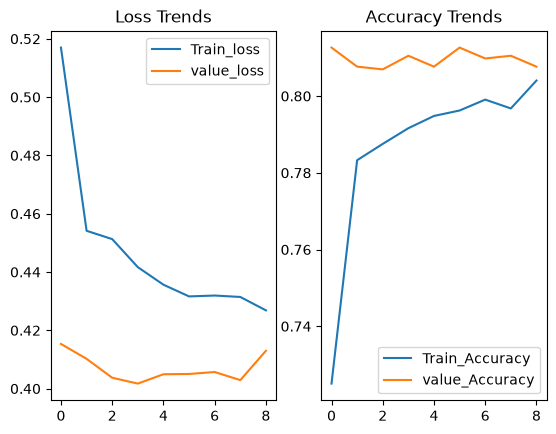

In [117]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
plt.plot(history.history['loss'],label="Train_loss")
plt.plot(history.history['val_loss'],label='value_loss')
plt.title("Loss Trends")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label="Train_Accuracy")
plt.plot(history.history['val_accuracy'],label='value_Accuracy')
plt.title("Accuracy Trends")
plt.legend()


In [118]:
import seaborn as sns

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
🎯 Mathematically Optimal Threshold: 0.3022


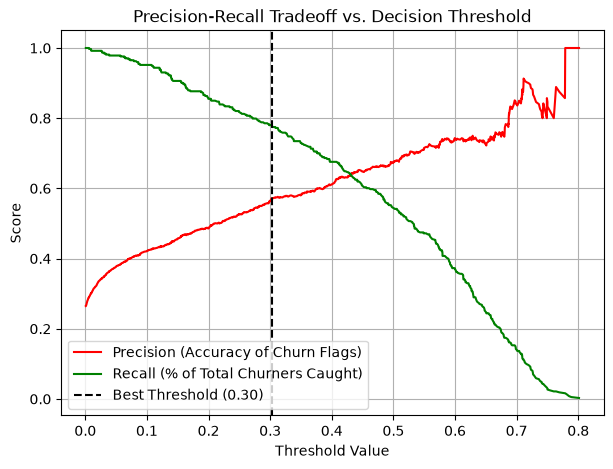

In [119]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# 1. Get raw probability scores from your model
y_pred_probs = model.predict(x_test).ravel()

# 2. Calculate precisions and recalls for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs)

# 3. Find the best threshold using F1-score (harmonic mean of precision & recall)
# Avoid division by zero by adding a tiny epsilon
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"🎯 Mathematically Optimal Threshold: {best_threshold:.4f}")

# 4. Plot the tradeoff curve
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision (Accuracy of Churn Flags)", color="red")
plt.plot(thresholds, recalls[:-1], label="Recall (% of Total Churners Caught)", color="green")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Best Threshold ({best_threshold:.2f})")
plt.title("Precision-Recall Tradeoff vs. Decision Threshold")
plt.xlabel("Threshold Value")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:
               precision    recall  f1-score   support

Non-churn (0)       0.91      0.79      0.84      1036
  Churned (1)       0.57      0.78      0.66       373

     accuracy                           0.79      1409
    macro avg       0.74      0.78      0.75      1409
 weighted avg       0.82      0.79      0.80      1409



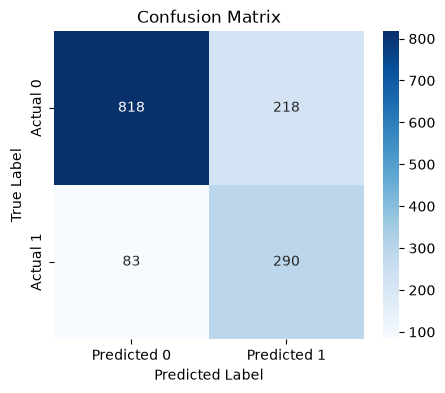

In [120]:
from sklearn.metrics import classification_report,confusion_matrix
y_prediction_prob=model.predict(x_test)

y_prediction=(y_prediction_prob>best_threshold ).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_prediction, target_names=['Non-churn (0)', 'Churned (1)']))

# 4. Plot a clean, visual Confusion Matrix
cm = confusion_matrix(y_test,y_prediction)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [124]:


# 1. Load your saved pipeline assets
with open("preprocessor.pkl", "rb") as f:
    loaded_preprocessor = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    loaded_le = pickle.load(f)

loaded_model = tf.keras.models.load_model("ann_churn_model.keras")


# 2. Define a brand new unseen customer profile (Must match original DataFrame structure)
new_customer = pd.DataFrame([{
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 70.70,
    'TotalCharges': 151.65
}])


# 3. Transform the profile using your loaded Pickle preprocessor
processed_customer = loaded_preprocessor.transform(new_customer)

# 4. Predict probability and apply your custom threshold (e.g., 0.25)
predicted_prob = loaded_model.predict(processed_customer)[0][0]
prediction_class = 1 if predicted_prob > 0.25 else 0

# 5. Reverse transform the binary answer back into a readable word string
churn_status = loaded_le.inverse_transform([prediction_class])[0]

print(f"🔮 Churn Probability: {predicted_prob:.2%}")
print(f"📋 Model Decision: Customer status is likely '{churn_status}'")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
🔮 Churn Probability: 68.41%
📋 Model Decision: Customer status is likely 'Yes'
